### We load a real tabular dataset. <br>
### Goal: <br> - inspect shape, <br> - class balance, <br> - feature scale before touching a model. <br>

### I expect features on very different scales, which will matter for gradient descent.

In [1]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

data = load_breast_cancer()
X , y = data.data, data.target

print("X shape:", X.shape)
print("y shape:", y.shape)
print("class balance:", np.bincount(y))
print("\nfeature means (first 5):", X.mean(axis=0)[:5].round(2))
print("feature stds (first 5):", X.std(axis=0)[:5].round(2))

X shape: (569, 30)
y shape: (569,)
class balance: [212 357]

feature means (first 5): [1.4130e+01 1.9290e+01 9.1970e+01 6.5489e+02 1.0000e-01]
feature stds (first 5): [3.520e+00 4.300e+00 2.428e+01 3.516e+02 1.000e-02]


Splitting before scaling to prevent leakage. Stratifying to preserve the 212/357 class ratio in both sets. Fitting the scaler on train only, then transforming both.

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.20,
    random_state = RANDOM_STATE,
    stratify = y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("train", X_train.shape, "test:", X_test.shape)
print("train class balance:", np.bincount(y_train))
print("test class balance:", np.bincount(y_test))
print("\nscaled train mean (first 5):", X_train.mean(axis=0)[:5].round(3))
print("scaled train std (first 5):", X_train.std(axis=0)[:5].round(3))
print("scaled test mean (first 5):", X_test.mean(axis=0)[:5].round(3))

train (455, 30) test: (114, 30)
train class balance: [170 285]
test class balance: [42 72]

scaled train mean (first 5): [-0.  0. -0.  0.  0.]
scaled train std (first 5): [1. 1. 1. 1. 1.]
scaled test mean (first 5): [0.086 0.048 0.085 0.092 0.072]


In [3]:
print("all 30 means — max abs:", np.abs(X_train.mean(axis=0)).max())
print("all 30 stds  — min:", X_train.std(axis=0).min(), "max:", X_train.std(axis=0).max())


all 30 means — max abs: 5.6770217342700865e-15
all 30 stds  — min: 0.9999999999999984 max: 1.000000000000001


In [4]:
print("min value in scaled train:", X_train.min().round(3))
print("max value in scaled train:", X_train.max().round(3))


min value in scaled train: -2.715
max value in scaled train: 11.658


### Converting to float32 tensors

### Reshaping targets to (N,1) to match network output and avoid silent broadcasting.

In [5]:
X_train_t =torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1,1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1,1)

for name, t in [("X_train", X_train_t),("y_train", y_train_t),
                ("X_test", X_test_t), ("y_test", y_test_t)]:
                print(f"{name:8} shape={tuple(t.shape)} dtype={t.dtype}")

X_train  shape=(455, 30) dtype=torch.float32
y_train  shape=(455, 1) dtype=torch.float32
X_test   shape=(114, 30) dtype=torch.float32
y_test   shape=(114, 1) dtype=torch.float32


In [6]:
(y_train_t.reshape(-1) - torch.zeros(455, 1)).shape

torch.Size([455, 455])

### Wrapping training tensors in a DataLoader for mini-batch gradient descent.

### Batch size 32. Shuffling train only — test order is irrelevant and shuffling it would only obscure debugging.

In [7]:
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32

train_ds = TensorDataset(X_train_t, y_train_t) #Pair each X row with its y row so they never drift out of sync
train_loader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True) # Handles shuffling and slicing into batches.

print("batches per epoch:", len(train_loader))

xb, yb = next(iter(train_loader)) #next(iter(loader)) is standard trick for peeking at a single batch without writing a loop
print("one batch - X:", tuple(xb.shape), " y:", tuple(yb.shape))

batches per epoch: 15
one batch - X: (32, 30)  y: (32, 1)


### Defining an MLP
    - 30 Inputs
    - 16 hidden (ReLU)
    - 8  hidden (ReLU)
    - 1  Output


In [8]:
class MLPClassifier(nn.Module):
    def __init__(self, n_features, n_hidden1=16, n_hidden2=8):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, n_hidden1),
            nn.ReLU(),
            nn.Linear(n_hidden1, n_hidden2),
            nn.ReLU(),
            nn.Linear(n_hidden2, 1),
        )

    def forward(self, x):
        return self.net(x)

model = MLPClassifier(n_features=30)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print("total trainable parameters:", n_params)

MLPClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=1, bias=True)
  )
)
total trainable parameters: 641


### BCEWithLogitLoss:
    - fuses sigmoid + BCE for numerical stability.
    - model outputs raw logits.
    - Adam optimiser, lr 0.001 (Default)

In [9]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("loss:", criterion)
print("optimizer:", optimizer.__class__.__name__)

loss: BCEWithLogitsLoss()
optimizer: Adam


### TRAINING LOOP
    For each epoch:
        - iterate batches
        - runs the 5 train steps(
            O- Optimizer.zero_grad()
            0- Outputs= models(xb)
            l- loss=criterion(Outputs,yb)
            l- loss.backward()
            0- Optimizer.step()
        )
        - accumulate loss for reporting
        - Track train and test loss per epoch to watch overfitting
        - model.train() & model.eval() toggle layer behaviour

In [10]:
N_EPOCHS = 50

train_losses = []
test_losses = []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    train_losses.append(epoch_loss / len(train_ds))

    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_t)
        test_loss = criterion(test_logits, y_test_t)
    test_losses.append(test_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"epoch {epoch+1:3d}  train_loss {train_losses[-1]:.4f}   test_loss {test_losses[-1]:.4f}")

epoch  10  train_loss 0.2517   test_loss 0.2668
epoch  20  train_loss 0.0695   test_loss 0.1029
epoch  30  train_loss 0.0466   test_loss 0.0903
epoch  40  train_loss 0.0376   test_loss 0.0893
epoch  50  train_loss 0.0309   test_loss 0.0917


### Plotting train vs test loss to visualise the overfitting gap.
    - Then converting test logits to class predictions.
    - Sigmoid -> threshold at 0.5.
    - Reporting accuracy plus the confusion matrix.
    - 0=malignant , 1=benign 

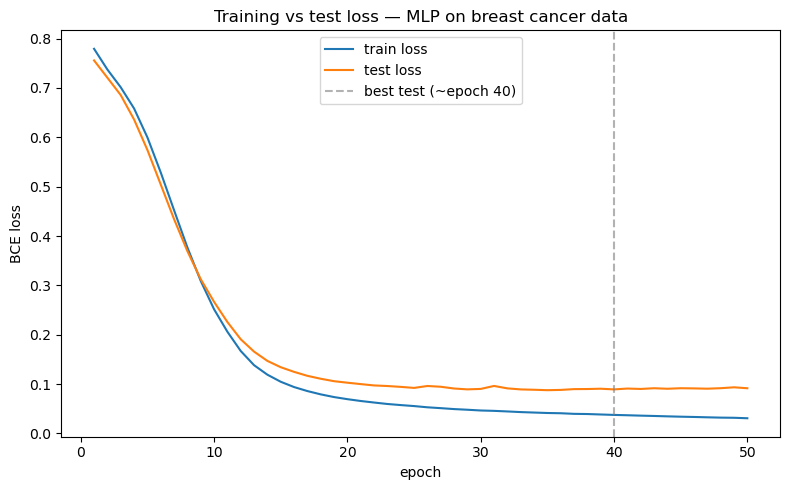

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, N_EPOCHS + 1), train_losses, label="train loss")
plt.plot(range(1, N_EPOCHS + 1), test_losses, label="test loss")
plt.axvline(40, color="gray", linestyle="--", alpha=0.6, label="best test (~epoch 40)")
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("Training vs test loss — MLP on breast cancer data")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model.eval()
with torch.no_grad(): # Inference, No gradients
    test_logits = model(X_test_t)
    test_probs = torch.sigmoid(test_logits)
    test_preds = (test_probs >= 0.5).float() # Threshold turning probabilities into hard 0/1 predictions.

y_true = y_test_t.numpy().ravel() #ravel flattens the 114,1 column back to (114,) for sklearns metrics
y_pred = test_preds.numpy().ravel()

print("accuracy:", round(accuracy_score(y_true, y_pred), 4))
print("\nconfusion matrix:")
print(confusion_matrix(y_true, y_pred))
print("\nclassification report:")
print(classification_report(y_true, y_pred, target_names=["malignant (0)", "benign (1)"]))

accuracy: 0.9561

confusion matrix:
[[41  1]
 [ 4 68]]

classification report:
               precision    recall  f1-score   support

malignant (0)       0.91      0.98      0.94        42
   benign (1)       0.99      0.94      0.96        72

     accuracy                           0.96       114
    macro avg       0.95      0.96      0.95       114
 weighted avg       0.96      0.96      0.96       114

